# ISLP Chapter 3 Lab
#### Author: Thomas Fitzgerald
This notebook contains my work for the lab accompanying Chapter 3 of [*An Introduction to Statistical Learning with Python* ("*ISLP*")](https://www.statlearning.com/). The third chapter of *ISLP* focuses on linear regression (both simple and multiple regression). This lab covers use of both regression cases using the libraries introduced in the previous lab (**numpy**. **pandas**, and **matplotlib**) as well as portions of the **statsmodels** and **ISLP** libraries. Other considerations when using linear regression are discussed at the end of the lab. To begin, the required libraries are imported:

In [2]:
# Note: "!pip install ISLP" can be executed to install the required libraries 
# tools used in first lab
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

# new tools 
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

### Inspecting Objects and Namespaces
The **dir()** function can be used to obtain a list of objects in a namespace. This displays everything that **Python** can find at the top level. Every object in **Python** has its own notation in namespace that includes its methods and attributes. This is demostrated for a **numpy** array below.

In [4]:
A = np.array([1, 2, 3])
dir(A)

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_prepare__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__buffer__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',
 '

## Simple Linear Regression
In this section, model matrices (a.k.a. design matrices) are constructed using the **ModelSpec()** transform from the **ISLP.models**. First, data from the **Boston** data set is loaded. This data includes median home value ("**medv**") for 506 neighborhoods around Boston as well as 13 predictor fields. 

In [6]:
Boston = load_data("Boston")
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

Next, the **statsmodels** library can be used to generate a regression model. However, a single predictor must be selected to make this a simple linear regression. In this case, the single selected predictor is the **lstat** variable (which records the share of households of low socioeconomic status) and the response is **medv**. The model matrix for this problem consists of a column of all ones for the intercept and a column for the **lstat** variables. This is produced as follows:

In [8]:
X = pd.DataFrame({'intercept':np.ones(Boston.shape[0]), 'lstat':Boston['lstat']})
X[:2]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14


Next, the response is extracted and the model is fit using the **sm.OLS()** (that is ordinary least square) as the model. The results of the fit can be displayed using the **summarize()** function.  

In [10]:
Y = Boston['medv']
model = sm.OLS(Y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


### Using Transformations: Fit and Transforms
The model demostrated above is quite rudimentary. In practice, models may include many predictors and it may be useful to apply transformations to the predictors, account for interactions, or expand some variables (e.g. polynomials). The Sci-kit learn ("**sklearn**") library has a specific name for this task - a *transform*. A transform is an object that is created with some parameters as an argument and has two main methods: **fit()** and **transform()**. The authors of *ISLP* included a general approach for specifying models and generating model matrices through the **ISLP.models.ModelSpec()** function (imported as **MS** in this lab). **ModelSpec** creates a transform object with **fit()** and **transform()** methods that are used to construct the model matrix. The **fit()** method takes the initial array and may do some computations on it (such as centering and scaling). The **transform()** method applies the specified transformations to the data array and produces the model matrix. This process is demonstrated below: 

In [12]:
design = MS(['lstat'])
design = design.fit(Boston)
X = design.transform(Boston)
X[:2]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14


In this case, the **fit()** method is simply used to check if the **lstat** field is present in the **Boston** data set. Then, **transform()** constructs the model matrix with two columns: an intercept and the variable **lstat**. These two operations can be combined in the **fit_transform()** method.

In [14]:
design = MS(['lstat']) 
X = design.fit_transform(Boston)
X[:2]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14


The authors note that, when the two steps are carried out separately, the **fit()** method changes the **design** object. The power of this pipeline is not immediately clear, but will be elucidated as more complex models are used.

Returning to the regression model fitted earlier in this lab, it should be noted that the **results** variable can also be summarized using the **summary()** method. This method provides more in-depth metrics on the results of the regression than provided by the **summarize()** function. Additionally, the fitted coefficients can be retrieved as the **params** attributes of **results**.

In [16]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Wed, 04 Feb 2026   Prob (F-statistic):           5.08e-88
Time:                        16:42:39   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [17]:
results.params

intercept    34.553841
lstat        -0.950049
dtype: float64

The **get_prediction()** method can be used to obtain predictions given a set of observed values. To get predictions, a data frame must be produced with observed values for the predictors. Next, this data frame must be transformed (easily accomplished using the **transform()** method of **design**). The **get_prediction()** method returns an object of type **PredctionResult** which carries information on the predictions. Mean predictions can be extracted from the onject using the **predicted_mean** attribute.

In [19]:
new_df = pd.DataFrame({'lstat':[5, 10, 15]})
new_X = design.transform(new_df)
predictions = results.get_prediction(new_X)
predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

The **conf_int()** method can be used on the **predictions** variable to return a condidence interval with a specified level of confidence. The **alpha** keyword is used to specify the desired level of confidence (note the confidence interval is $1 - \mathbf{alpha}$). The **obs** keyword can be specified as **True** to return the prediction interval.  

In [21]:
conf_int = predictions.conf_int(alpha=0.05)
pred_int = predictions.conf_int(obs=True, alpha=0.05)
conf_int, pred_int

(array([[29.00741194, 30.59977628],
        [24.47413202, 25.63256267],
        [19.73158815, 20.87461299]]),
 array([[17.56567478, 42.04151344],
        [12.82762635, 37.27906833],
        [ 8.0777421 , 32.52845905]]))

### Defining Functions
This section introduces the process of defining and implementing functions in **Python**. First, the book sets up a function to add a line to a plot. Note, the **\*args** and **\*\*kwargs** arguments allow for passing a dynamic number of positional and keyword arguments.

In [23]:
def abline(ax, b, m, *args, **kwargs):
    # add a line with slope m and intercept b to the plot ax
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

This function can now be used to add a line to the plot of **medv** vs. **lstat**.

C:\Users\susan\AppData\Local\Temp\ipykernel_10128\1011879434.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results.params[0], results.params[1], 'r--', linewidth=3)


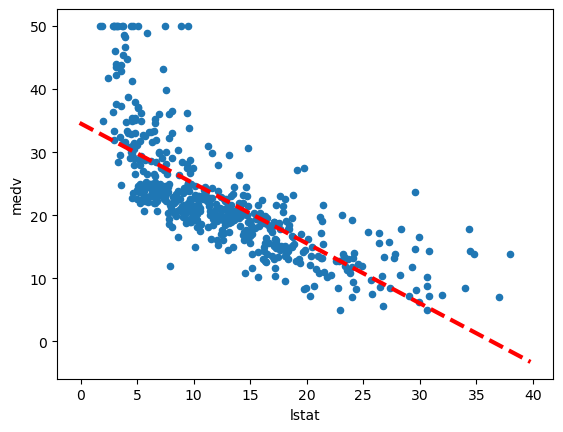

In [25]:
ax = Boston.plot.scatter('lstat', 'medv')
abline(ax, results.params[0], results.params[1], 'r--', linewidth=3)
ax;

Next, some diagnostic plots are examined. The **results** object carries infomration on the fitted values and residuals of the fit. Various influence measures can be calculated using the **get_influence()** method. The following example uses only the **ax** value of **suplots()**.

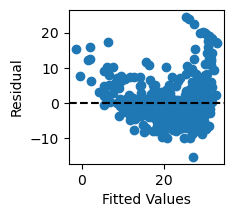

In [27]:
ax = subplots(figsize=(2, 2))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

The horizontal dashed line indicates the points for which the residual is zero. The **c** keyword determines the color of the line (in this case black) and the **ls** keyword defines the line style (in this case dashed). The resulting residual plot indicates some non-linearity in the model. Using the **hat_matrix_diag** attribute of the result of the **get_influence()** method, leverage statistics can be computed for any number of predictors. This is demonstrated below:

374

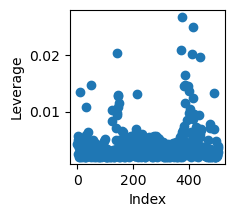

In [29]:
infl = results.get_influence()
ax = subplots(figsize=(2,2))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

The **np.argmax()** function identifies the index of the largest element of an array (this can optionally be computed over an axis of the array). In the example above, the maximum is taken from the whole array to find the index with the highest leverage statistic.

## Multiple Linear Regression
The **ModelSpec()** transform to construct the required model matrix and response for a multiple linear regression. The arguments to **ModelSpec()** can be quite general. In the example below, a list of column names suffices. For the example, the predictors **lstat** and **age** are considered. 

In [31]:
X = MS(['lstat', 'age']).fit_transform(Boston)
model1 = sm.OLS(Y, X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


On datasets with many predictors, it can be cumbersome to construct the model matrix via the method used above. The following process can be used when the model will use all predictors. 

In [33]:
terms = Boston.columns.drop('medv')
terms

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

As can be seen, this is a simple approch. The **terms** data frame is constructed by dropping the response column from the **Boston** data set.

In [35]:
X = MS(terms).fit_transform(Boston)
model = sm.OLS(Y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


This process can be expanded upon to drop other columns that are not of interest. For example, in the above, the **age** and **indus** predictors have very high p-values. This indicates that there is strong evidence that they may not be influential on the response (e.g. it is possible their coefficient should be zero). To drop these columns, the following code can be used.

In [37]:
trimmed_terms = Boston.columns.drop(['medv', 'indus', 'age'])
trimmed_terms

Index(['crim', 'zn', 'chas', 'nox', 'rm', 'dis', 'rad', 'tax', 'ptratio',
       'lstat'],
      dtype='object')

In [38]:
X = MS(trimmed_terms).fit_transform(Boston)
model = sm.OLS(Y, X)
summarize(model.fit())

,coef,std err,t,P>|t|
intercept,41.4517,4.903,8.454,0.000
crim,-0.1217,0.033,-3.696,0.000
zn,0.0462,0.014,3.378,0.001
chas,2.8719,0.863,3.329,0.001
nox,-18.2624,3.565,-5.122,0.000
rm,3.6730,0.409,8.978,0.000
dis,-1.5160,0.188,-8.078,0.000
rad,0.2839,0.064,4.440,0.000
tax,-0.0123,0.003,-3.608,0.000
ptratio,-0.9310,0.130,-7.138,0.000


## Multivariate Goodness of Fit
Components of the **results** object can be accessed by name (**dir(results)** lists the available components). The **results.rsquared** gives the $R^2$ and **np.sqrt(result.scale)** gives the RSE. Variance inflation factors ("VIFs") are sometimes useful to the assess the effect of collinearity in the model matrix of a regression model. In the following section, the VIFs of the multiple regression fit are computed and the idea of list comprehension is introduced.

### List Comprehension
During analysis, sequences of objects need to be transformed for some task. Below, the VIFs are computed for each feature in the **X** matrix and a data frame is produced whose columns agree with the columns of **X**. List comprehensions are simple and powerful ways to for lists of **Python** objects. The language also provides dictionary and generator comprehensions (though these are not covered in this section). Below is an example of list comprehension:

In [62]:
vals = [VIF(X, i) for i in range(1, X.shape[1])]
vif = pd.DataFrame({'vif':vals}, index=X.columns[1:])
vif

,vif
crim,1.765478
zn,2.239107
chas,1.056997
nox,3.758338
rm,1.819577
dis,3.438955
rad,6.826385
tax,7.258419
ptratio,1.755565
lstat,2.527415


The function **VIF()** takes two arguments a dataframe (or array) and a variable column index. The code above calls **VIF()** for all columns in **X** (excluding column 0, which is the intercept column). The following code is equivalent when creating **vif**: 

In [67]:
vals = []
for i in range(1, X.shape[1]):
    vals.append(VIF(X, i))

## Interaction Terms
**ModelSpec()** makes it easy to include interaction terms in a linear model. Simply, including a tuple ("**lstat**", "**age**") tells the model matrix builder to include an interaction term between the two terms. 

In [72]:
X = MS(['lstat', 'age', ('lstat', 'age')]).fit_transform(Boston)
model2 = sm.OLS(Y, X)
summarize(model2.fit())

,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


## Non-Linear Transformations of the Predictors
The **ModelSpec()** model matrix builder can also be used to perform non-linear transformation on the predictors in a data set. For example, the **poly()** function can be used to provide a polynomial transormation on a predictor.

In [75]:
X = MS([poly('lstat', degree=2), 'age']).fit_transform(Boston)
model3 = sm.OLS(Y, X)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


By default, **poly()** generates a basis matrix for inclusion in the model matrix whose columns are orthogonal polynomials (which are designed for stable least squares computations). The "**raw=True**" argument can be used to make a basis matrix consisting of only **lstat** and **lstat**$^2$. It is also important to note that the **poly()** function does not add an intercept column. 

The **anova_lm()** function can be used to further quantify the extent to which the quadratic fit is superior to the linear fit. Below, the function is used with **results1** (the linear submodel using **lstat** and **age**) and **results3** (the model with the quadratic **lstat** term).

In [85]:
anova_lm(results1, results3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


The **anova_lm()** model performs a hypothesis test comparing the two models. In this case, the null hypothesis is that the quadratic term in the non-linear model is not needed. The large F-statistic and negligible p-value provide string evidence that the quadratic term improves the model and that the non-linear model is superior. 

The **anova_lm()** function can compare more than one model at a time. With each row comparing to the previous (hence the NaN values in the first row as there is no previous row to compare to).

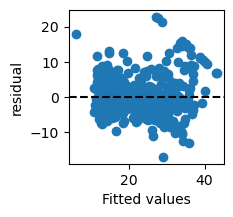

In [88]:
ax = subplots(figsize=(2, 2))[1]
ax.scatter(results3.fittedvalues, results3.resid)
ax.set_ylabel('residual')
ax.set_xlabel('Fitted values')
ax.axhline(0, c='k', ls='--')

As can be seen in the chart above, including the quadratic term causes the residual chart to lose any clear pattern in residuals.

## Qualitative Predictors
In this section, the **Carseats** data set is used to predict **Sales** based on a number of predictors. Unlike the **Boston** data set, the **Carseats** data set inculde qualitative predictors. For example, the **ShelveLoc** data includes a rating of the display location of the car seat (either **Bad**, **Medium**, or **Good**). Below, the data set is loaded and the columns displayed: 

In [94]:
Carseats = load_data('Carseats')
Carseats.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

The **ModelSpec()** function automatically creates dummy variables for qualitative predictors. These variables are often referred to as *one-hot encoding* of the categorical feature. The columns of the dummy variables sum to 1 and, to avoid collinearity with an intercept, the first term is dropped (in the case of **ShelveLoc** the **Bad** column is dropped. Below, a multiple regression line including some interaction terms is fit to **Carseats**. 

In [100]:
allvars = list(Carseats.columns.drop('Sales'))
Y = Carseats['Sales']
final = allvars + [('Income', 'Advertising'), ('Price', 'Age')]
X = MS(final).fit_transform(Carseats)
model = sm.OLS(Y, X)
summarize(model.fit())

,coef,std err,t,P>|t|
intercept,6.5756,1.009,6.519,0.000
CompPrice,0.0929,0.004,22.567,0.000
Income,0.0109,0.003,4.183,0.000
Advertising,0.0702,0.023,3.107,0.002
Population,0.0002,0.000,0.433,0.665
Price,-0.1008,0.007,-13.549,0.000
ShelveLoc[Good],4.8487,0.153,31.724,0.000
ShelveLoc[Medium],1.9533,0.126,15.531,0.000
Age,-0.0579,0.016,-3.633,0.000
Education,-0.0209,0.020,-1.063,0.288


As can be seen above, **ModelSpec()** produced several dummy variables for the qualitative predictors of the **Carseats** data set. The positive coefficients for **ShelveLoc[Good]** and **ShelveLoc[Medium]** indicate that better shelf locations are associated with higher sales.